##Lending Club Loan Data Analysis
Objective: Create a model that predicts whether or not a loan will be default using historical data.

In [109]:
# Suppress noisy TensorFlow logs before importing
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

#  Third party imports
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import tensorflow as tf
import itertools
import time

#from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score, log_loss, accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
#from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, MinMaxScaler
from sklearn.utils.class_weight import compute_sample_weight

from pathlib import Path
from shutil import rmtree
from typing import Tuple, Optional

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard

In [72]:
%pip install tensorboard

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [110]:
#Global TensorFlow training configuration
# Remove and recreate logs directory to clear any old TensorBoard logs
log_dir = ('../logs')
rmtree(log_dir, ignore_errors=True)
Path(log_dir).mkdir(parents=True, exist_ok=True)

# Set verbosity for wherever it's accepted
verbose = 0

# Fix TensorFlow random state for reproducibility
tf.random.set_seed(315)

In [117]:
# 1.1 Load the dataset
df = pd.read_csv("../data/loan_data.csv")
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [112]:
#1.1 Transform the Data
# Check for missing values
print('Missing values per column:')
display(df.isnull().sum())

# Check for duplicate rows
print('\nNumber of duplicate rows:')
display(df.duplicated().sum())

Missing values per column:


credit.policy        0
purpose              0
int.rate             0
installment          0
log.annual.inc       0
dti                  0
fico                 0
days.with.cr.line    0
revol.bal            0
revol.util           0
inq.last.6mths       0
delinq.2yrs          0
pub.rec              0
not.fully.paid       0
dtype: int64


Number of duplicate rows:


np.int64(0)

In [118]:
# 1.1 Transform / Preprocess the Loan Dataset by removing unnecessary features, encoding categorical variables, and creating training and test splits.

#Drop columns that are not needed for the analysis
#df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

# Define the label
label = 'not.fully.paid'

# Define numerical features to apply IQR clipping
numerical_features = ['credit.policy','int.rate','installment','log.annual.inc','dti','fico','days.with.cr.line','revol.bal','revol.util','inq.last.6mths','delinq.2yrs','pub.rec']

# Define ordinal features to encode
#ordinal_features = ['education_level', 'income_level']

# Define ordinal categories in order
#education_categories = [['No formal', 'Highschool', 'Graduate', 'Postgraduate']]
#income_categories = [['Low', 'Lower-Middle', 'Middle', 'Upper-Middle', 'High']]

# Define features for one-hot encoding
nominal_features = ['purpose']

# Complete feature list
features = numerical_features + nominal_features

# Split the dataset into training and testing sets before applying feature engineering to ensure less data leakage. Use a 80/20 split for training and testing sets.
training_df, testing_df = train_test_split(df, test_size=0.2, random_state=42)

In [119]:
#1.1 Select the features of interest and the label
training_df = training_df[features + [label]]
testing_df = testing_df[features + [label]]

#1.1 Standard scale
feature_scaler = StandardScaler()
feature_scaler.fit(training_df[numerical_features])

training_df[numerical_features] = feature_scaler.transform(training_df[numerical_features])
testing_df[numerical_features] = feature_scaler.transform(testing_df[numerical_features])

#1.1 Clip outliers with IQR method
for feature in numerical_features:

    q1 = training_df[feature].quantile(0.25)
    q3 = training_df[feature].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    training_df[feature] = training_df[feature].clip(lower_bound, upper_bound)
    testing_df[feature] = testing_df[feature].clip(lower_bound, upper_bound)

In [120]:
#1.1 Nominal feature encoding (one-hot encoding)

onehot_encoder = OneHotEncoder(
    drop='first',
    sparse_output=False,
    handle_unknown='ignore'
)

onehot_encoder.fit(training_df[nominal_features])

# Capture encoded features as DataFrame
encoded_features_df = pd.DataFrame(
    onehot_encoder.transform(training_df[nominal_features]),
    columns=onehot_encoder.get_feature_names_out(nominal_features)
)

# Remove original nominal features and add encoded versions
training_df = pd.concat([
    training_df.drop(columns=nominal_features).reset_index(drop=True),
    encoded_features_df.reset_index(drop=True)
], axis=1)

training_df.reset_index(drop=True, inplace=True)

# Repeat for testing data
encoded_features_df = pd.DataFrame(
    onehot_encoder.transform(testing_df[nominal_features]),
    columns=onehot_encoder.get_feature_names_out(nominal_features)
)

testing_df = pd.concat([
    testing_df.drop(columns=nominal_features).reset_index(drop=True),
    encoded_features_df.reset_index(drop=True)
    ], axis=1)

testing_df.reset_index(drop=True, inplace=True)

In [121]:
training_df.head()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_major_purchase,purpose_small_business
0,0.492566,0.868707,0.049122,-1.535031,-0.172101,-0.498260,0.268636,-0.520199,-0.608169,-0.266751,-0.298831,-0.239131,0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.492566,-1.431963,-0.391757,0.475451,-0.948919,0.811133,-0.566438,-0.388802,-0.208769,-0.714472,-0.298831,-0.239131,0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.492566,-0.283480,-0.865503,0.385937,-0.837116,0.156437,-0.302347,-0.144915,0.882696,-0.266751,-0.298831,-0.239131,0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.492566,-1.083713,1.015832,0.203709,-0.616412,0.549255,-0.194484,0.766412,1.333743,-0.714472,-0.298831,-0.239131,1,0.0,0.0,0.0,0.0,0.0,0.0
4,0.492566,-0.364985,-0.024503,-0.393163,0.935774,1.203951,0.992200,-0.514108,-1.437958,-0.266751,-0.298831,-0.239131,0,0.0,0.0,0.0,0.0,1.0,0.0


KeyError: 'purpose_credit_card'

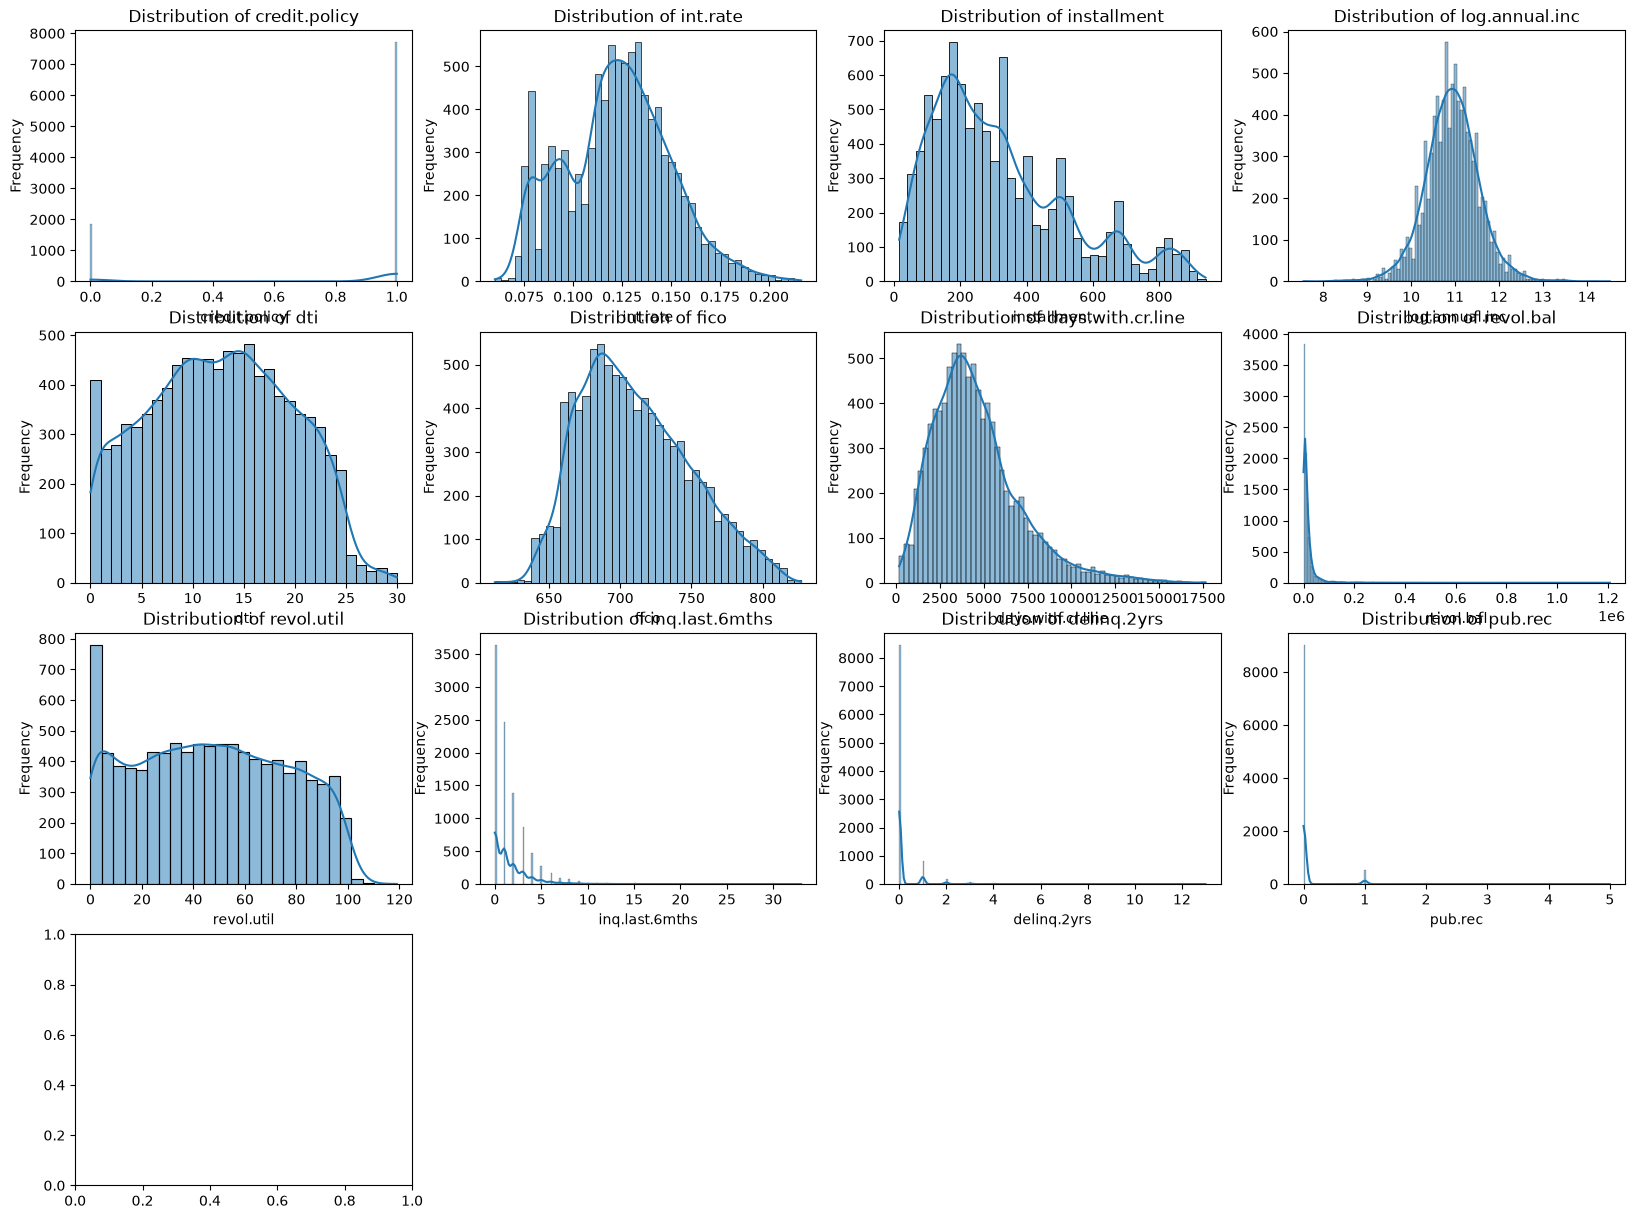

In [122]:
#2. Exploratory data analysis of different factors in the dataset.
# EDA - Visualize distributions of key numerical features
# subset of relevant numerical columns for plotting
numerical_features = ['credit.policy','int.rate','installment','log.annual.inc','dti','fico','days.with.cr.line','revol.bal','revol.util','inq.last.6mths','delinq.2yrs','pub.rec'
,'purpose_credit_card','purpose_debt_consolidation','purpose_educational','purpose_home_improvement','purpose_major_purchase','purpose_small_business']

plt.figure(figsize=(20, 15))
for i, feature in enumerate(numerical_features):
    plt.subplot(4, 4, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [123]:
#2 Target imbalance - utilize Class weights
from sklearn.utils.class_weight import compute_class_weight

print(training_df[label].value_counts(normalize=True))

classes = np.unique(training_df[label])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=training_df[label].to_numpy()
)
class_weight_dict = dict(zip(classes, class_weights))
print(f"Class weights: {class_weight_dict}")

not.fully.paid
0    0.839729
1    0.160271
Name: proportion, dtype: float64
Class weights: {np.int64(0): np.float64(0.5954305253341623), np.int64(1): np.float64(3.1197068403908794)}


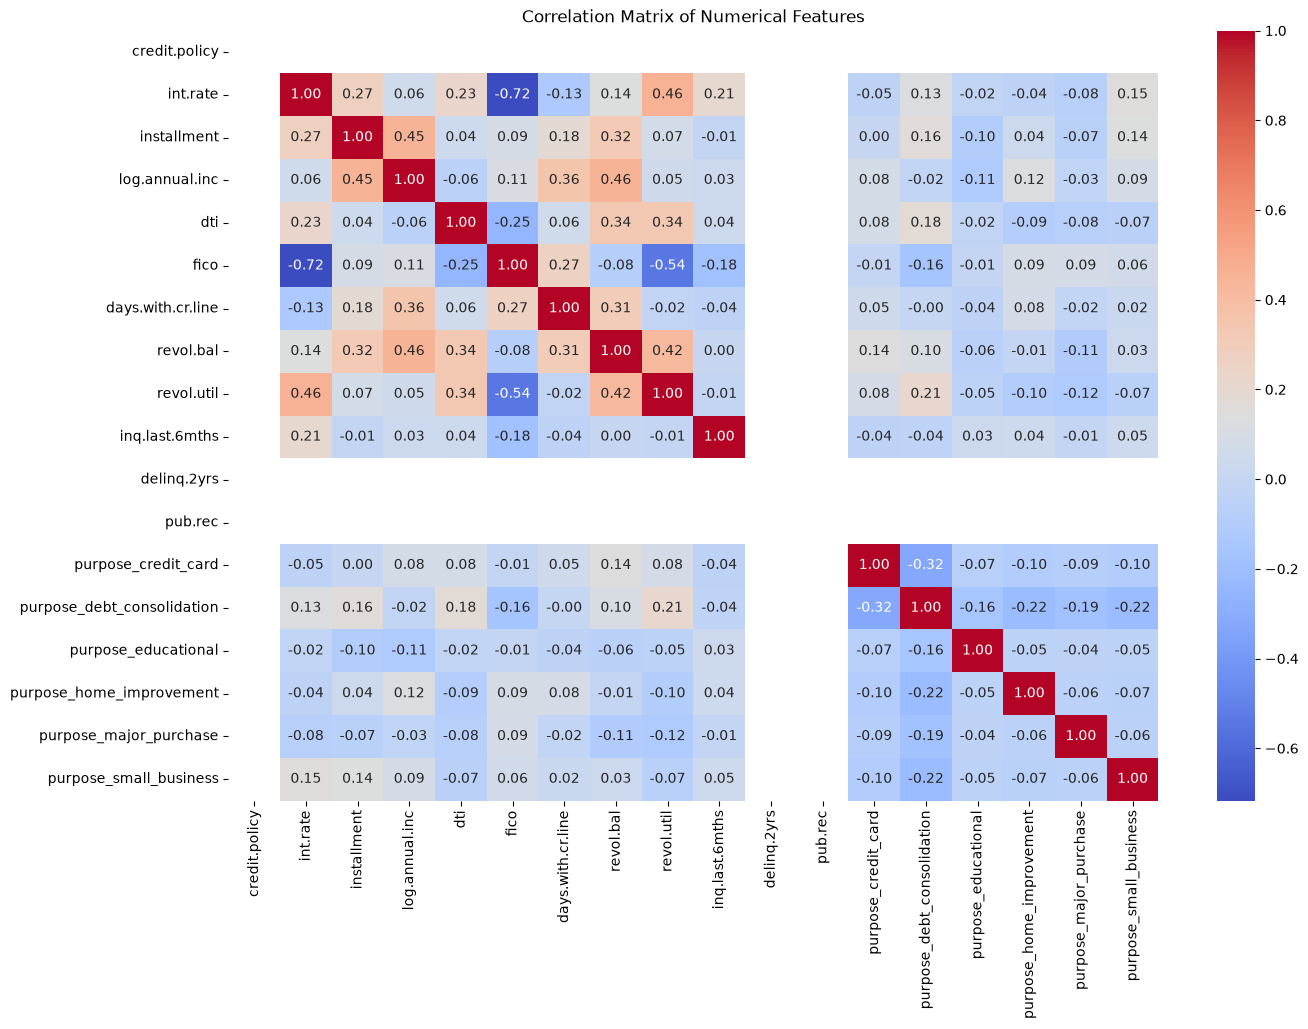

Features to drop due to high correlation: ['fico']


In [124]:
#3. Additional Feature Engineering - You will check the correlation between features and drop those features that have a strong correlation.
correlation_matrix = training_df[numerical_features].corr()
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Identify highly correlated features and drop one of each pair
# mask the diagonal/lower triangle and threshold absolute values; that drops one later-listed feature for each correlated pair, including inverse pairs.
# fico unforetunately is highly correlated with other features and may need to be dropped - consider the threshold.

threshold = 0.65
corr_matrix = training_df[numerical_features].corr()
upper_triangle = corr_matrix.abs().where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
to_drop = [
    column for column in upper_triangle.columns
    if (upper_triangle[column] > threshold).any()
]
print(f"Features to drop due to high correlation: {to_drop}")

In [125]:
# Drop highly correlated features based on the threshold
training_df = training_df.drop(columns=to_drop, errors='ignore')
testing_df = testing_df.drop(columns=to_drop, errors='ignore')
features = [column for column in training_df.columns if column != label]

In [126]:
#4. Modeling
#Callback constructor function
def make_callbacks(
    learning_rate: float,
    batch_size: int,
    patience: int = 10,
) -> Tuple[keras.callbacks.EarlyStopping, keras.callbacks.TensorBoard]:
    '''Create EarlyStopping and TensorBoard callbacks.'''

    early_stopping = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience,
        verbose=verbose
    )

    run_log_dir = f'{log_dir}/lr_{learning_rate}_bs_{batch_size}'

    Path(run_log_dir).mkdir(parents=True, exist_ok=True)

    tensorboard_callback = keras.callbacks.TensorBoard(
        log_dir=run_log_dir,
        histogram_freq=1,
        write_graph=False
    )

    return early_stopping, tensorboard_callback

In [127]:
#4. Modeling
# Model constructor function - Keras / Tensorflow
def build_model(learning_rate: float=0.01) -> keras.Sequential:
    '''Builds and compiles the Keras Sequential model.'''

    model = keras.Sequential([
        layers.Input(shape=(len(features),)),
        layers.Dense(16, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

In [128]:
#4 Model training function
def train_model(
    model: keras.Sequential,
    epochs: int=100,
    batch_size: int=128,
    validation_split: Optional[float]=0.2,
    callbacks: Tuple[keras.callbacks.EarlyStopping, keras.callbacks.TensorBoard]=None
) -> Tuple[keras.Sequential, keras.callbacks.History]:
    '''Trains the Keras Sequential model. Returns the training history.'''

    history = model.fit(
        training_df[features],
        training_df[label],
        epochs=epochs,
        batch_size=batch_size,
        validation_split=validation_split,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=verbose
    )

    return model, history

In [129]:
#4 Optimize batch size and learning rate
#import time
#%%time

batch_sizes = [256, 512, 1024]
learning_rates = [1e-6, 1e-5, 1e-4]

for batch_size, learning_rate in itertools.product(batch_sizes, learning_rates):

    print(f'Batch size: {batch_size}, learning rate: {learning_rate}...', end='\t')

    # Set-up callback for this run
    callbacks = make_callbacks(learning_rate=learning_rate, batch_size=batch_size)

    # Build and train the model
    model = build_model(learning_rate=learning_rate)
    model, history = train_model(model, batch_size=batch_size, callbacks=callbacks)

    print(f"final val loss: {history.history['val_loss'][-1]:.4f}, ", end=' ') 
    print(f"final val accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")

print()


Batch size: 256, learning rate: 1e-06...	final val loss: 0.7359,  final val accuracy: 32.75%
Batch size: 256, learning rate: 1e-05...	final val loss: 0.6922,  final val accuracy: 51.53%
Batch size: 256, learning rate: 0.0001...	final val loss: 0.6854,  final val accuracy: 54.66%
Batch size: 512, learning rate: 1e-06...	final val loss: 0.7528,  final val accuracy: 30.92%
Batch size: 512, learning rate: 1e-05...	final val loss: 0.6533,  final val accuracy: 65.49%
Batch size: 512, learning rate: 0.0001...	final val loss: 0.6447,  final val accuracy: 61.06%
Batch size: 1024, learning rate: 1e-06...	final val loss: 0.5698,  final val accuracy: 84.15%
Batch size: 1024, learning rate: 1e-05...	final val loss: 0.7457,  final val accuracy: 27.92%
Batch size: 1024, learning rate: 0.0001...	final val loss: 0.6663,  final val accuracy: 60.47%



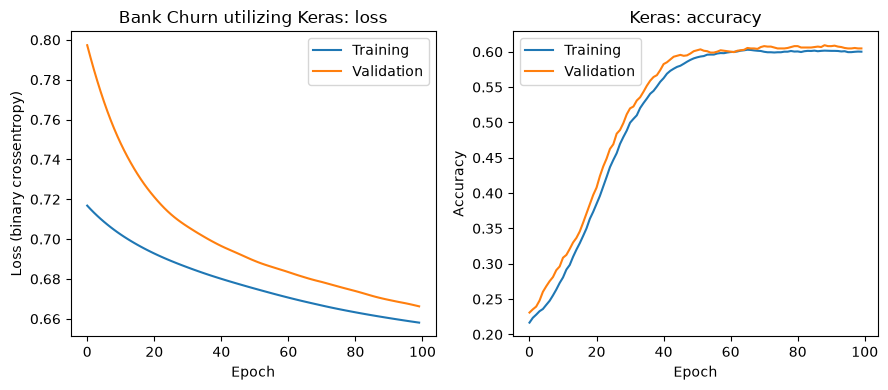

In [130]:
#4. Learning curves
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].set_title('Bank Churn utilizing Keras: loss')
axes[0].plot(history.history['loss'], label='Training')
axes[0].plot(history.history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (binary crossentropy)')
axes[0].legend(loc='best')

axes[1].set_title('Keras: accuracy')
axes[1].plot(history.history['accuracy'], label='Training')
axes[1].plot(history.history['val_accuracy'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

In [131]:
#4. Evaluation
sequential_probs = model.predict(testing_df[features], verbose=0).flatten()
sequential_predictions = (sequential_probs >= 0.5).astype(int)
sequential_accuracy = accuracy_score(testing_df[label], sequential_predictions)

print(f'Optimized model accuracy on test set: {sequential_accuracy:.4f}')

Optimized model accuracy on test set: 0.6028


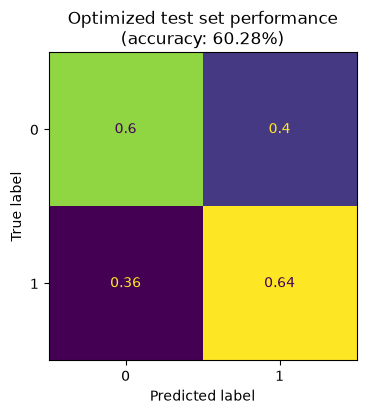

In [132]:
#4. Performance analysis - ConfusionMatrix
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))

ax.set_title(f'Optimized test set performance\n(accuracy: {sequential_accuracy:.2%})')

disp = ConfusionMatrixDisplay.from_predictions(
    testing_df[label],
    sequential_predictions,
    normalize='true',
    ax=ax,
    colorbar=False
)